In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 2.0 #NOTE: changed!
N_SEGS = 12  # must match --n-segs used to build the LHS seed
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

# Mojito light EMRI_G
# m1 = 6.72e5
# m2 = 9.84e1
# a = 0.5
# p0 = 15.7117
# e0 = 0.7440
# xI0 = 1.0
# dist = 4.755
# qS = 0.5906
# phiS = 3.5808
# qK = 1.1707
# phiK = 3.8495
# Phi_phi0 = 3.1940
# Phi_theta0 = 3.3780
# Phi_r0 = 0.6038

def icrs_to_ecliptic(qK_icrs, phiK_icrs, eps_deg=23.43929111):
    """
    Convert a sky direction (colatitude, longitude) from the ICRS/equatorial
    frame (qK = pi/2 - dec, phiK = ra) to the ecliptic frame (SSB frame used
    by the LISA response, is_ecliptic_latitude=False convention) via the
    standard equatorial<->ecliptic rotation with J2000 mean obliquity eps.
    """
    dec = np.pi / 2 - qK_icrs
    ra = phiK_icrs
    eps = np.deg2rad(eps_deg)

    sin_beta = np.sin(dec) * np.cos(eps) - np.cos(dec) * np.sin(ra) * np.sin(eps)
    beta = np.arcsin(sin_beta)

    y = np.cos(dec) * np.sin(ra) * np.cos(eps) + np.sin(dec) * np.sin(eps)
    x = np.cos(dec) * np.cos(ra)
    lam = np.arctan2(y, x) % (2 * np.pi)

    qK_ecl = np.pi / 2 - beta
    phiK_ecl = lam
    return qK_ecl, phiK_ecl

# Mojito light EMRI_C
# m1 = 3.54e6
# m2 = 8.01e1
# a = 0.950
# p0 = 7.3890
# e0 = 0.3160
# xI0 = 1.0000
# dist = 4.858
# qS = 2.0420
# phiS = 5.7873
# qK, phiK = icrs_to_ecliptic(1.6633, 1.7431)  # catalog qK/phiK are in ICRS, convert to ecliptic
# Phi_phi0 = 2.4044
# Phi_theta0 = 0.2850
# Phi_r0 = 0.9743

# Mojito light EMRI_F
m1 = 1.00e7
m2 = 1.00e1
a = 0.998
p0 = 2.1200
e0 = 0.4250
xI0 = 1.0
dist = 4.313
qS = 0.6280
phiS = 1.2561
qK, phiK = icrs_to_ecliptic(2.7000, 2.6200)  # catalog qK/phiK are in ICRS, convert to ecliptic
Phi_phi0 = 4.1163
Phi_theta0 = 1.4444
Phi_r0 = 0.9810

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS, phase_max=True))
        except Exception:
            pass
    return out


def prior_transform(u):
    # logm1lim = [5.6,  6.4]
    # logm2lim = [0.8, 1.3]
    # alim = [0.3, 0.99]
    # p0lim = [8.0, 11.0]
    # e0lim = [0.2, 0.5]
    # qSlim = [0.0, np.pi]
    # phiSlim = [0.0, 2 * np.pi]
    # logm1lim = [5.6,  6.4]
    # logm2lim = [1.7, 2.3]
    # alim = [0.3, 0.99]
    # p0lim = [13.5, 16.5]
    # e0lim = [0.6, 0.9]
    # cosqSlim = [-1.0, 1.0]      # cos(qS): source colatitude, sampled uniform in cosine
    # phiSlim = [0.0, 2 * np.pi]

    # EMRI F
    # a lower bound raised from 0.9 -> 0.95: at a<~0.95 the Kerr separatrix
    # for e0 up to 0.55 rises above the whole p0 range (e.g. sep=2.89 at
    # a=0.9, e0=0.55 vs. p0 in [1.8, 2.6]), so that corner is 100% unphysical
    # and produces the near-separatrix draws that crash FEW's interpolator
    # (fatal "Error in fit_wrap" in interpolate.cu, not a catchable exception).
    logm1lim = [6.6,   7.4]
    logm2lim = [0.7,   1.3]
    alim = [0.95,  0.999]
    p0lim = [1.8,   2.6]
    e0lim = [0.3,   0.55]
    cosqSlim = [-1.0,  1.0]
    phiSlim = [0.0,  2*np.pi]

    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    # EMRI F
    logm1lim = [6.6,   7.4]
    logm2lim = [0.7,   1.3]
    alim = [0.95,  0.999]
    p0lim = [1.8,   2.6]
    e0lim = [0.3,   0.55]
    cosqSlim = [-1.0,  1.0]
    phiSlim = [0.0,  2*np.pi]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u

Using dt=10s, T=2.0yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_f/stage1_merge_s12/'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [ ]:
sampler.now_covariances

[array([[ 4.84731629e-02,  3.32720343e-02, -1.83671371e-02,
         -9.46188847e-03,  3.78655173e-03,  1.51111070e-03,
          1.27773887e-04],
        [ 3.32720343e-02,  2.37632173e-01,  1.56303491e-02,
          9.35861481e-04,  1.76419389e-03,  1.18618983e-03,
         -1.06795776e-02],
        [-1.83671371e-02,  1.56303491e-02,  8.57679522e-02,
         -3.55447268e-02, -6.51327228e-03,  1.66931344e-03,
          4.74484075e-03],
        [-9.46188847e-03,  9.35861481e-04, -3.55447268e-02,
          7.86536218e-02,  2.46085960e-02, -4.33661687e-03,
         -6.48663817e-03],
        [ 3.78655173e-03,  1.76419389e-03, -6.51327228e-03,
          2.46085960e-02,  1.14862303e-01,  1.09219065e-03,
         -4.54708536e-04],
        [ 1.51111070e-03,  1.18618983e-03,  1.66931344e-03,
         -4.33661687e-03,  1.09219065e-03,  9.60985397e-02,
          1.66554159e-02],
        [ 1.27773887e-04, -1.06795776e-02,  4.74484075e-03,
         -6.48663817e-03, -4.54708536e-04,  1.66554159e-02

In [ ]:
len(sampler.now_covariances)

1

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.90326028, 0.77890869, 0.99247265, 2.50389884, 0.51223168,
        0.03639563, 1.04549358]])

In [7]:
log_density(maxld_pt1)

array([17.98085784])

In [8]:
log_density([param_true])

array([55.47636735])

In [9]:
param_ranges = [(6.6,  7.4),
                (0.7,   1.3),
                (0.95,  0.999),
                (1.8,   2.6),
                (0.3,   0.55),
                (-1,1),
                (0.0, 2 * np.pi)
                ]
param_ranges


[(6.6, 7.4),
 (0.7, 1.3),
 (0.95, 0.999),
 (1.8, 2.6),
 (0.3, 0.55),
 (-1, 1),
 (0.0, 6.283185307179586)]

In [10]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[7.0, 1.0, 0.998, 2.12, 0.425, 0.8092041809880323, 1.2561]

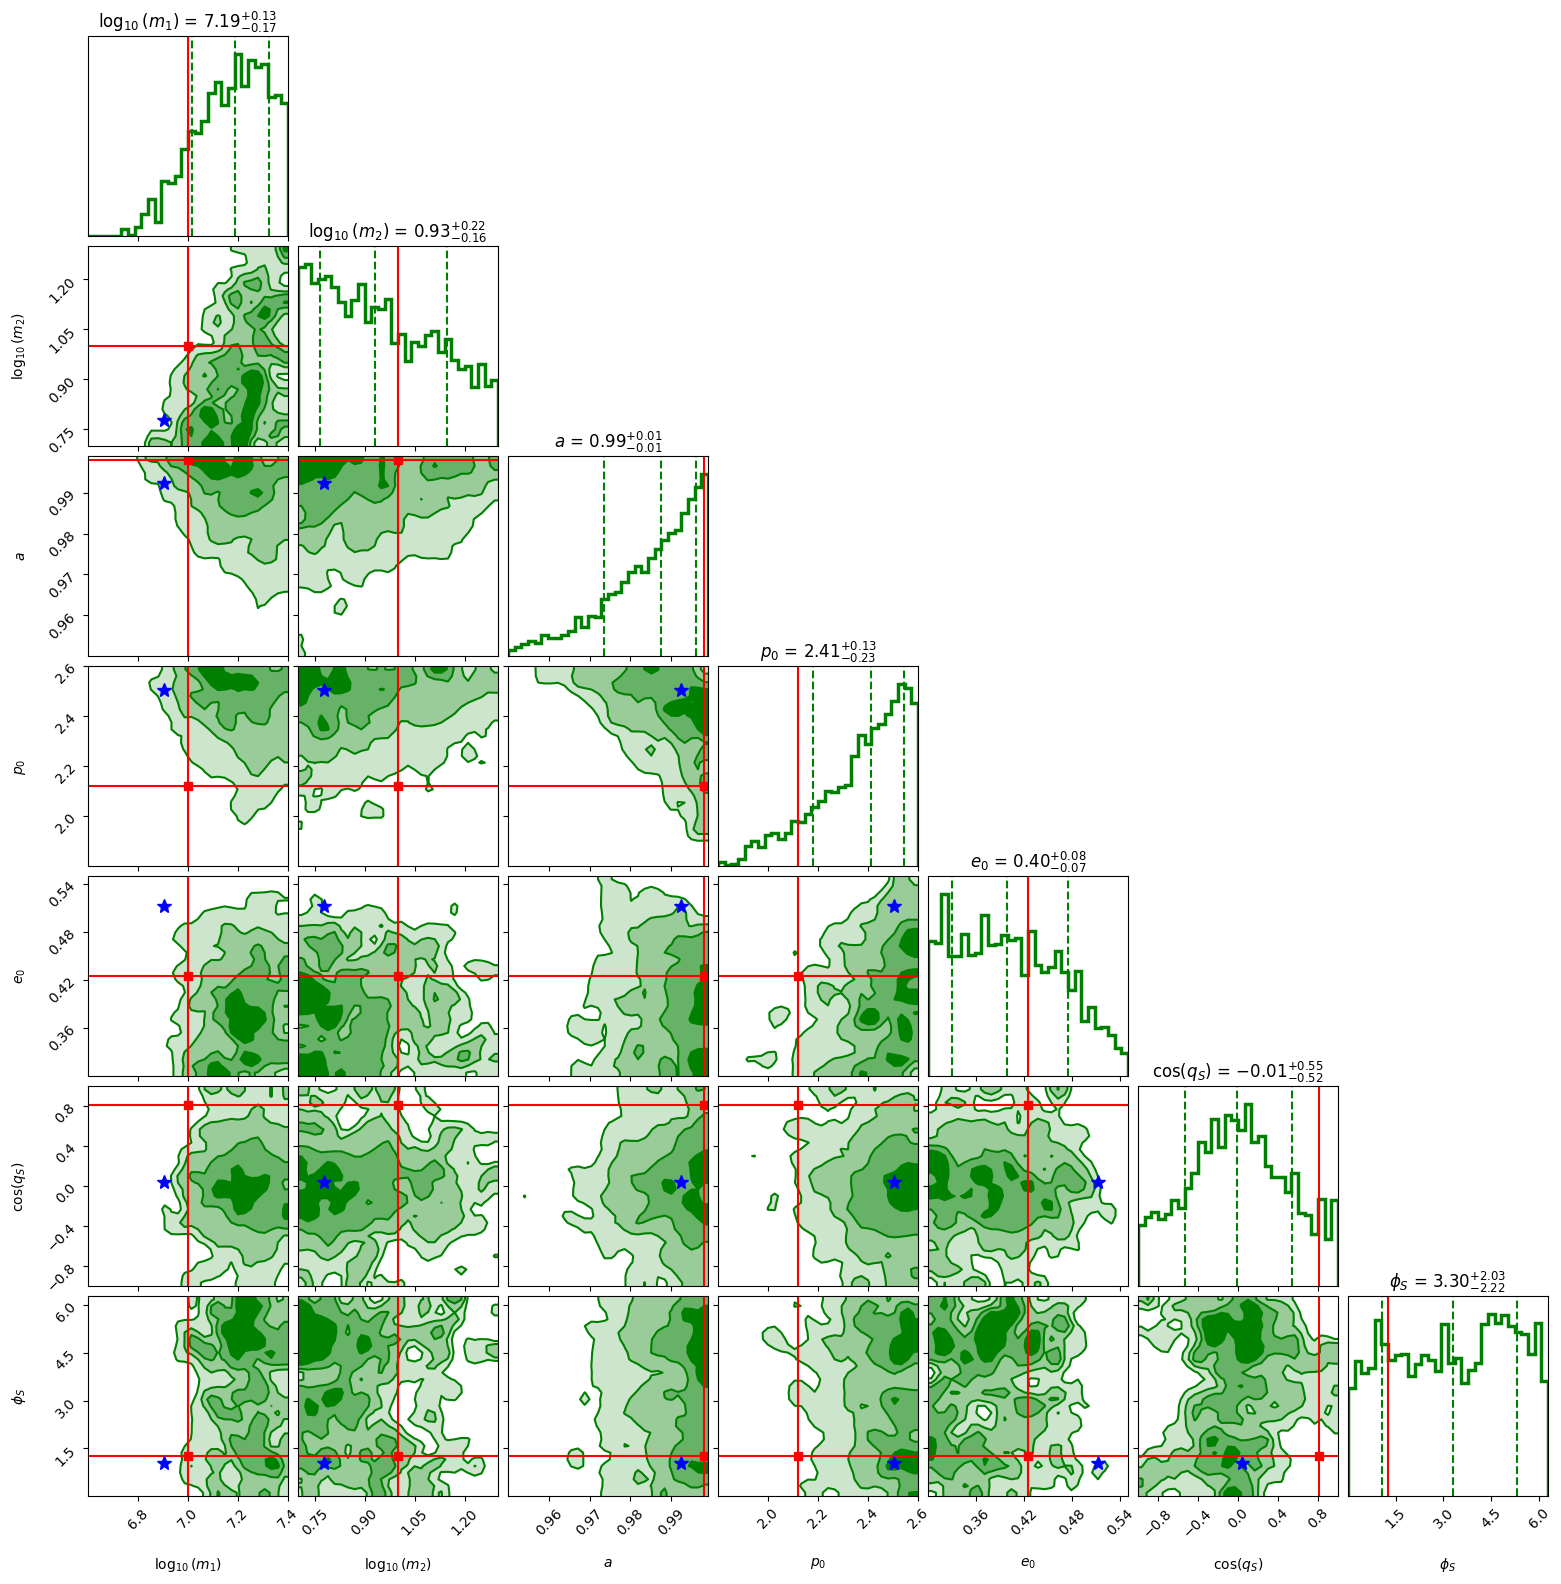

In [11]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)


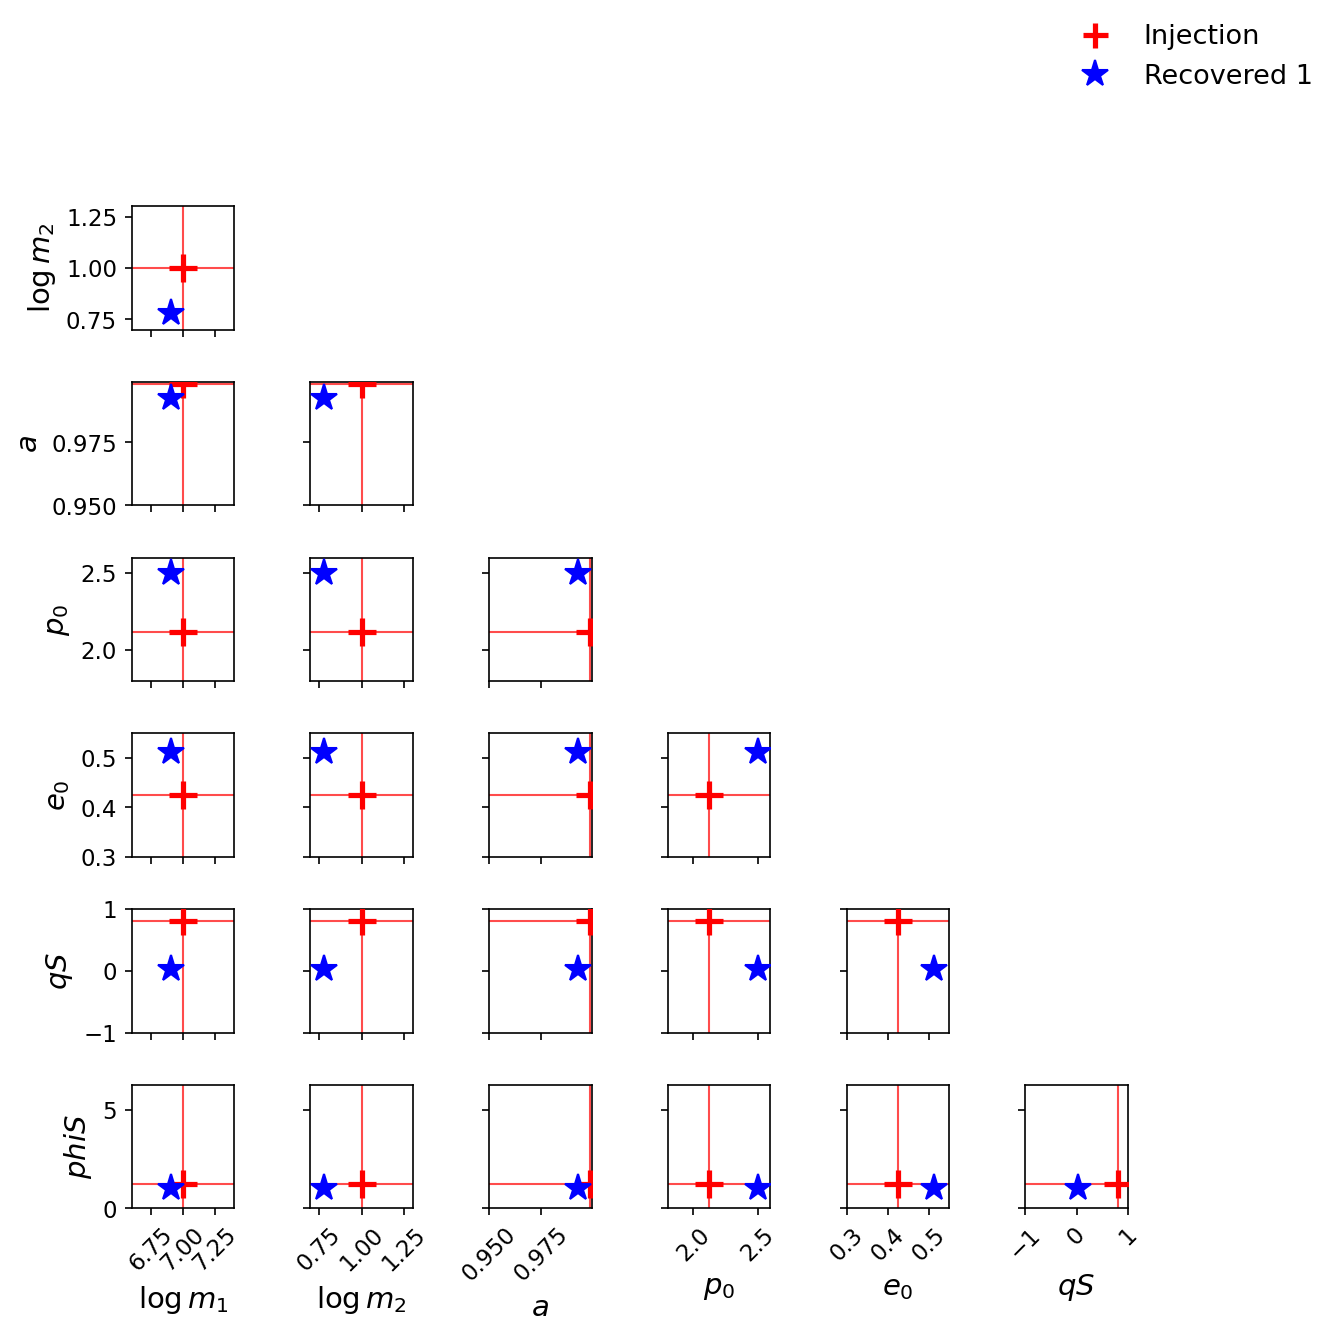

In [12]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()
# maxld_pt2  = np.asarray(maxld_pt2).ravel()
# maxld_pt3  = np.asarray(maxld_pt3).ravel()
# maxld_pt4  = np.asarray(maxld_pt4).ravel()
# maxld_pt5  = np.asarray(maxld_pt5).ravel()
# maxld_pt6  = np.asarray(maxld_pt6).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)
        # # recovered MAP point
        # ax.plot(maxld_pt2[j], maxld_pt2[i], '*', color='orange',
        #         ms=13, zorder=4)
        # # recovered MAP point
        # ax.plot(maxld_pt3[j], maxld_pt3[i], '*', color='pink',
        #         ms=13, zorder=4)
        # ax.plot(maxld_pt4[j], maxld_pt4[i], '*', color='purple',
        #         ms=13, zorder=4)
        # ax.plot(maxld_pt5[j], maxld_pt5[i], '*', color='brown',
        #         ms=13, zorder=4)
        # ax.plot(maxld_pt6[j], maxld_pt6[i], '*', color='black',
        #         ms=13, zorder=4)
        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
    # Line2D([0], [0], color='orange', marker='*', ls='', ms=13,          label='Recovered 2'),
    # Line2D([0], [0], color='pink', marker='*', ls='', ms=13,          label='Recovered 3'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [13]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[6.90326028, 0.77890869, 0.99247265, 2.50389884, 0.51223168,
        0.03639563, 1.04549358]])

In [14]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [15]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [16]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


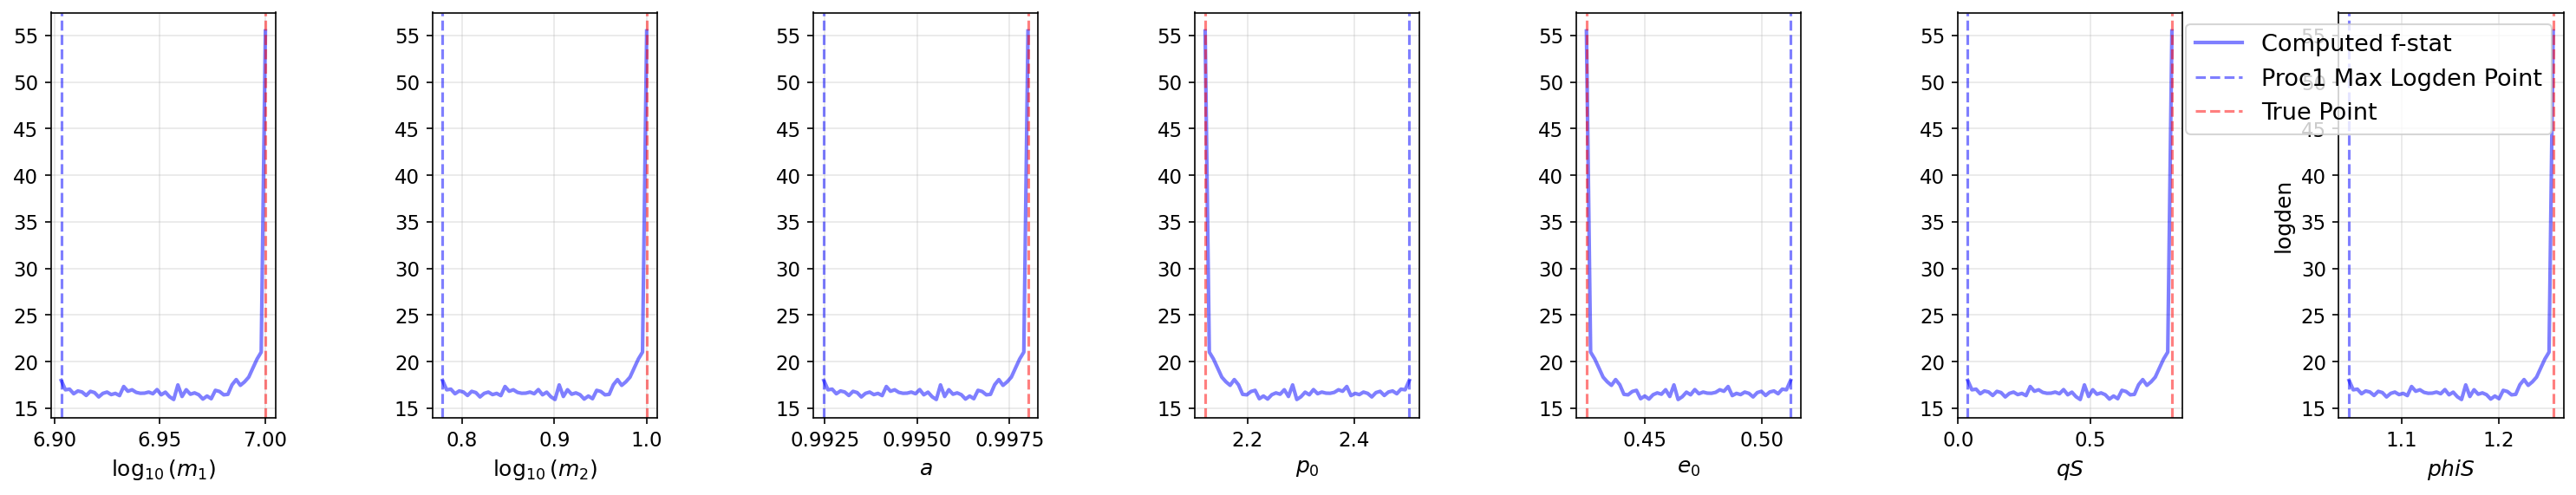

In [17]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [18]:
import numpy as np

def sky_antipode(qS, phiS):
    """
    Antipodal sky point: qS -> pi - qS, phiS -> phiS + pi (mod 2pi).
    qS: colatitude [rad], phiS: azimuth [rad].
    """
    qS_anti = np.pi - qS
    phiS_anti = (phiS + np.pi) % (2 * np.pi)
    return qS_anti, phiS_anti

# EMRI_C true values
qS_true, phiS_true = 2.0420, 5.7873
qS_anti, phiS_anti = sky_antipode(qS_true, phiS_true)

print(f"qS_true={qS_true:.4f}  phiS_true={phiS_true:.4f}  cos(qS_true)={np.cos(qS_true):.5f}")
print(f"qS_anti={qS_anti:.4f}  phiS_anti={phiS_anti:.4f}  cos(qS_anti)={np.cos(qS_anti):.5f}")


qS_true=2.0420  phiS_true=5.7873  cos(qS_true)=-0.45396
qS_anti=1.0996  phiS_anti=2.6457  cos(qS_anti)=0.45396


In [19]:
maxld_pt1

array([6.90326028, 0.77890869, 0.99247265, 2.50389884, 0.51223168,
       0.03639563, 1.04549358])

In [20]:
from few.trajectory.inspiral import EMRIInspiral
from few.utils.constants import YRSID_SI

traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_traj, p_traj, e_traj, xI_traj, Phi_phi, Phi_theta, Phi_r = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T
)

t_plunge_sec = t_traj[-1]
t_plunge_yr = t_plunge_sec / YRSID_SI
print(f"Trajectory ends at t = {t_plunge_sec:.3e} s = {t_plunge_yr:.4f} yr")
print(f"Reached T={T} yr without plunging: {t_plunge_yr >= T - 1e-6}")

Trajectory ends at t = 6.312e+07 s = 2.0000 yr
Reached T=2.0 yr without plunging: True


In [21]:
t_traj, p_traj, e_traj, xI_traj, Phi_phi, Phi_theta, Phi_r = traj_gen(
    m1, m2, a, p0, e0, xI0, T=50  # yr, generous upper bound
)
t_plunge_sec = t_traj[-1]
print(f"True plunge time: {t_plunge_sec/YRSID_SI:.4f} yr")

True plunge time: 2.4870 yr


In [23]:
sampler.searched_points_list

[array([[ 0.356235  ,  0.101265  ,  0.872945  , ...,  0.841495  ,
          0.521735  ,  0.274835  ],
        [ 0.36015822,  0.12362447,  0.8970197 , ...,  0.84343404,
          0.53127148,  0.26292171],
        [ 0.3491492 ,  0.12508289,  0.90974329, ...,  0.83778863,
          0.53036703,  0.24268415],
        ...,
        [-0.08819452,  0.2333631 ,  1.20357038, ...,  0.71753214,
          0.52872532,  0.74366505],
        [ 0.4464136 ,  0.27537986,  1.25310632, ...,  0.61411337,
          0.79752188,  0.53887227],
        [ 0.56793745, -0.06081406,  0.88926401, ...,  0.14753905,
          0.34323212,  1.80214339]])]

In [25]:
def log_density_safe(params):
    params = np.asarray(params)
    in_bounds = np.abs(params[:, 5]) <= 1.0
    out = np.full(params.shape[0], -np.inf)
    if in_bounds.any():
        out[in_bounds] = log_density(params[in_bounds])
    return out

In [31]:
dist=4.313

closest approach to truth: index 24401 of 50000 frac_dist = 0.06710861468918915


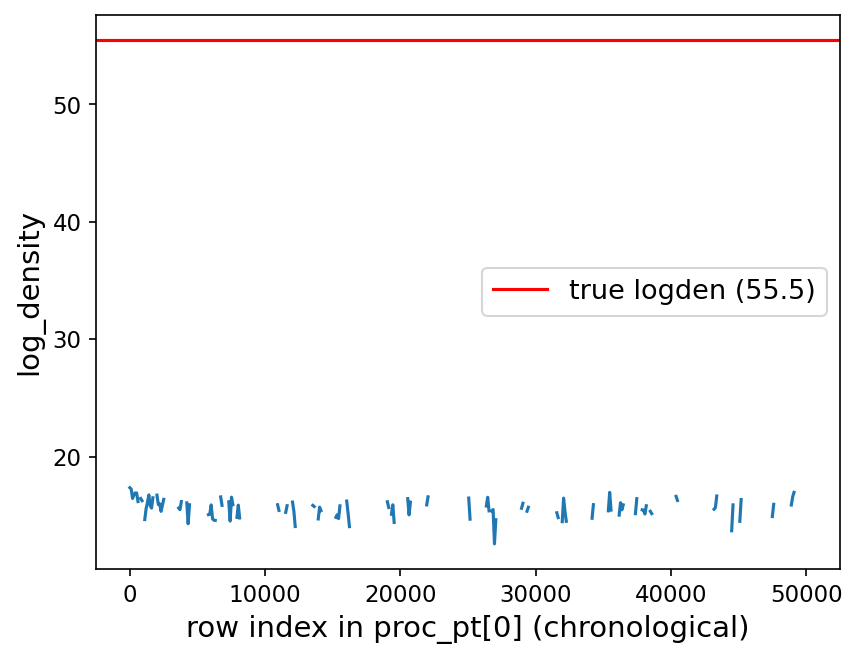

In [33]:
n_valid = sampler.element_num_list[0]           # filled length of the sole survivor
pts_norm = proc_pt[0][:n_valid]                 # full chronological history, normalized space
pts_phys = prior_transform(pts_norm)            # -> physical params

# distance to truth, normalized by prior width per dim (so all dims are comparable)
lo = np.array([r[0] for r in param_ranges])
hi = np.array([r[1] for r in param_ranges])
frac_dist = np.abs(pts_phys - np.array(param_true)) / (hi - lo)
dist_to_true = frac_dist.mean(axis=1)   # not `dist`
print('closest approach to truth: index', dist_to_true.argmin(), 'of', n_valid,
      'frac_dist =', dist_to_true.min())

# log-density trend over time (subsample — don't run all n_valid, it's expensive)
idx = np.linspace(0, n_valid - 1, 500).astype(int)
ld_hist = log_density_safe(pts_phys[idx])

import matplotlib.pyplot as plt
plt.plot(idx, ld_hist)
plt.axhline(log_density([param_true])[0], color='red', label='true logden (55.5)')
plt.xlabel('row index in proc_pt[0] (chronological)')
plt.ylabel('log_density')
plt.legend()

In [34]:
ld_hist

array([17.35286821, 17.23278989, 16.43625116, 16.74651414, 16.9104408 ,
       16.90604945, 16.17000925,        -inf, 16.43650758, 16.24364788,
              -inf, 14.64212301, 15.57566099, 16.10058799, 16.74051496,
       15.82832406, 15.61886069, 16.49125826,        -inf,        -inf,
       16.72137349, 15.91712368, 15.98003952, 15.33637889, 15.86479802,
       16.3599636 ,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf, 16.26784225,        -inf,
              -inf, 15.61729923, 15.48288408, 16.17279279,        -inf,
       14.56705082,        -inf, 16.06079743, 14.28388144, 15.89777986,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf, 16.43080314,
              -inf,        -inf,        -inf, 15.05867948, 15.10167961,
       15.88988921, 14.70452396, 14.58416157, 14.56780026,        -inf,
       15.73754182,        -inf, 16.56829123, 15.85143379,      

In [29]:

row = pts_phys[idx[0]]
logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = row
qS_i = np.arccos(np.clip(cos_qS_i, -1, 1))
h_temp = gwf.xp.array(waveform_response(
    10**logm1, 10**logm2, a_i, p0_i, e0_i,
    xI0, dist, qS_i, phiS_i, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
))

TypeError: Unsupported type <class 'numpy.ndarray'>

In [35]:
for k, (pts, lds) in enumerate(zip(sampler.archived_points, sampler.archived_log_densities)):
    print(f"archived process {k}: n={len(lds)}, max_logden={lds.max():.3f}")


archived process 0: n=620, max_logden=17.483
archived process 1: n=669, max_logden=17.336
archived process 2: n=1043, max_logden=17.482
archived process 3: n=1049, max_logden=17.344
archived process 4: n=1053, max_logden=17.474
archived process 5: n=1067, max_logden=17.378
archived process 6: n=1090, max_logden=17.385
archived process 7: n=1172, max_logden=17.489
archived process 8: n=1195, max_logden=17.651


In [38]:
m1 = 3.92e5
m2 = 1.02e1
a = 0.982
p0 = 14.5071
e0 = 0.4869
xI0 = 1.0
dist = 1.414
qS = 2.3901
phiS = 3.0970
qK, phiK = icrs_to_ecliptic(2.8061, 4.3612)  # -> qK=2.408879, phiK=4.542242
Phi_phi0 = 3.9227
Phi_theta0 = 5.8538
Phi_r0 = 6.2085


h_true = gwf.xp.array(waveform_response(
    m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
))
hf_true = gwf.freq_wave(h_true)
print(float(gwf.SNR(hf_true)))

74.64152111834937
